In [1]:
### Written by Myongin Oh
### Last updated on Aug 23, 2025

In [2]:
### Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from numpy.linalg import inv, norm, svd

In [5]:
dataFile = './final_feature_set.csv'     # Input dataset file name
cIndex = 10                          # Class index
### Initialize parameters
r = 2                                # Number of eigenvectors
eta = 1e-2                           # Initial step size
q = np.inf                           # Maximum step size
tau = np.finfo(float).eps            # Orthogonality criterion
eps = np.finfo(float).eps            # Convergence criterion

In [6]:
### Load dataset
T = pd.read_csv(dataFile)
X = T.iloc[:, 0:cIndex].values
Y = T.iloc[:, cIndex].values

In [7]:
# Find size of dataset (number of samples and number of features)
n, p = X.shape

In [8]:
# Find unique classes and number of classes
cls = np.unique(Y)
nc = len(cls)

In [9]:
# Set empty arrays for class sizes and class mean vectors
ncs = np.zeros(nc)
mu = np.zeros((nc, p))

In [10]:
# Find within-class scatter matrix
Sw = np.zeros((p, p))
for k in range(nc):
    ind = np.where(Y == cls[k])[0]
    ncs[k] = len(ind)                     # class sizes
    mu[k, :] = np.mean(X[ind, :], axis=0) # class mean vectors
    
    Sk = np.zeros((p, p))
    for i in range(len(ind)):
        Xc = X[ind[i], :] - mu[k, :]
        Sk += np.outer(Xc, Xc)
    Sw += inv(Sk)
Sw = inv(Sw)

In [11]:
# Define objective function
def J(W, nc, ncs, mu, Sw):
    f = 0
    for k in range(nc - 1):
        for l in range(k + 1, nc):
            mukl = mu[k, :] - mu[l, :]
            Bkl = np.outer(mukl, mukl)
            f += ncs[k] * ncs[l] * np.trace(W.T @ Sw @ W) / np.trace(W.T @ Bkl @ W)
    return f

In [12]:
# Set empty array for objective function values
Jvals = []

In [13]:
# Initialize W
W = np.random.randn(p, r)

In [14]:
# Compute initial gradient
grad = np.zeros((p, r))
for k in range(nc - 1):
    for l in range(k + 1, nc):
        mukl = mu[k, :] - mu[l, :]
        Bkl = np.outer(mukl, mukl)
        trBkl = np.trace(W.T @ Bkl @ W)
        trSw = np.trace(W.T @ Sw @ W)
        grad += 2 * ncs[k] * ncs[l] * (trBkl * Sw @ W - trSw * Bkl @ W) / (trBkl ** 2)

In [15]:
# Normalize initial gradient
xi = grad - W @ grad.T @ W
xih = xi / norm(xi, ord='fro')

In [16]:
# Perform gradient descent method
counter = 1
convergence = True
while convergence:
    # Compute and record current objective function value
    Jcurr = J(W, nc, ncs, mu, Sw)
    Jvals.append(Jcurr)
    print(f"Iter: {counter}, J: {Jcurr:.15e}, eta: {eta:.5e}")

    # Store current W and gradient
    Wo = W.copy()
    xio = xi.copy()
    xiho = xih.copy()
  
    # Update W using gradient descent method
    W = W - eta * xih
    
    # Check orthogonality to perform retraction
    # org = norm(W.T @ W - np.eye(r), ord='fro') / norm(np.eye(r), ord='fro')
    # if org > tau:
    U, _, Vt = svd(W, full_matrices=False)
    W = U @ Vt
    
    # Check termination condition
    Jw = J(W, nc, ncs, mu, Sw)
    Jo = J(Wo, nc, ncs, mu, Sw)
    if abs(Jw - Jo) / abs(Jo) < eps:
        convergence = False

    # Compute new gradient
    grad = np.zeros((p, r))
    for k in range(nc - 1):
        for l in range(k + 1, nc):
            Bkl = np.outer(mu[k, :] - mu[l, :], mu[k, :] - mu[l, :])
            trBkl = np.trace(W.T @ Bkl @ W)
            trSw = np.trace(W.T @ Sw @ W)
            grad += 2 * ncs[k] * ncs[l] * (trBkl * Sw @ W - trSw * Bkl @ W) / (trBkl ** 2)

    # Normalize new gradient
    xi = grad - W @ grad.T @ W
    xih = xi / norm(xi, ord='fro')
    
    # Perform random step adaptation with relaxation
    alpha = -0.9 + (1.8 + 0.9) * np.random.rand()
    numerator = (1 + alpha) * abs(np.trace(xio.T @ xiho))
    denominator = abs(np.trace(xio.T @ xiho) - np.trace(xi.T @ xiho))
    if numerator > q * denominator:
        eta = np.sqrt(q) * eta
    else:
        eta = np.sqrt(numerator / denominator) * eta

    if counter % 10 == 0:
        print("----------Iteration", counter, "----------")
        print("W", W)
        print("WTW", W.T @ W)
    
    # Increase number of iterations by one
    counter += 1

Iter: 1, J: 7.512481482960226e+12, eta: 1.00000e-02
Iter: 2, J: 6.436900222817322e+12, eta: 1.44984e-02
Iter: 3, J: 4.612281791695781e+12, eta: 3.17617e-02
Iter: 4, J: 2.687714799143839e+12, eta: 3.77959e-02
Iter: 5, J: 1.735098314435071e+12, eta: 3.23423e-02
Iter: 6, J: 1.323352726144219e+12, eta: 5.38704e-02
Iter: 7, J: 9.509469163072374e+11, eta: 1.22818e-01
Iter: 8, J: 5.782100284157146e+11, eta: 1.65567e-01
Iter: 9, J: 3.616330616938928e+11, eta: 2.08512e-01
Iter: 10, J: 2.346455947968724e+11, eta: 3.40843e-01
----------Iteration 10 ----------
W [[-0.29845154 -0.47726285]
 [ 0.38727022 -0.33693034]
 [ 0.08890377 -0.19775774]
 [ 0.2675603   0.46559204]
 [-0.0572812   0.36877332]
 [-0.10123973  0.409657  ]
 [-0.23697066 -0.03792564]
 [ 0.06644935 -0.30677399]
 [ 0.77867483 -0.05809381]
 [-0.03194274 -0.00882552]]
WTW [[1.00000000e+00 3.00938635e-16]
 [3.00938635e-16 1.00000000e+00]]
Iter: 11, J: 1.422311252972967e+11, eta: 6.58158e-01
Iter: 12, J: 7.846084952432045e+10, eta: 1.13542

In [17]:
# Show result
print(W)

[[-0.45909412 -0.37837329]
 [ 0.50035527  0.1272311 ]
 [-0.52120362 -0.0613994 ]
 [ 0.01263037  0.62496998]
 [-0.44884095  0.42603114]
 [-0.09744208  0.26615285]
 [-0.07026453  0.11991856]
 [-0.06126922 -0.23330173]
 [ 0.15452638 -0.08634895]
 [-0.1534336   0.34304863]]


In [18]:
# Save W as CSV file
np.savetxt('W_oHLDA.csv', W, delimiter=',')

C:\Users\myongino\AppData\Local\Temp\ipykernel_31956\1466922445.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


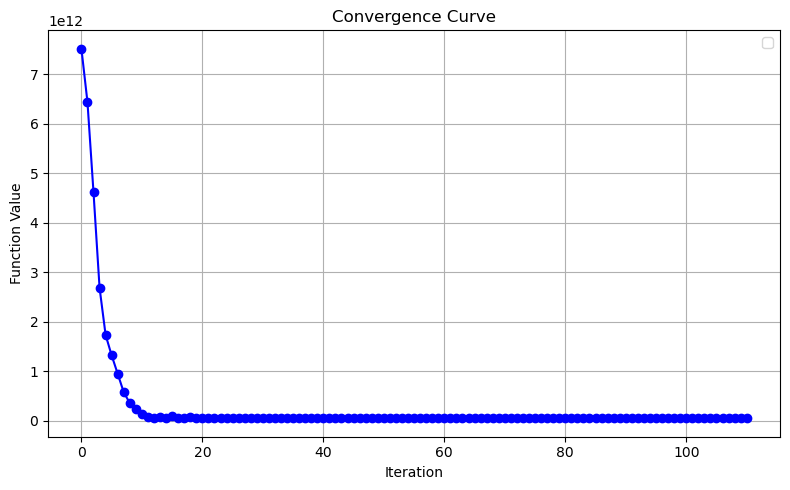

<Figure size 640x480 with 0 Axes>

In [19]:
# Draw convergence curve
plt.figure(figsize=(8, 5))
plt.plot(Jvals, marker='o', color='blue')
plt.title('Convergence Curve')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("convergence_curve.png", dpi=300)

In [20]:
### STEP 9. Transform the samples onto the new subspace
Xlda = X @ W

dfc1 = pd.DataFrame(Xlda[Y==0])
dfc1.columns =['ld1','ld2']
dfc1.to_csv('oHLDA_class1_bpso_mi.csv', encoding='utf-8', index=False)
dfc2 = pd.DataFrame(Xlda[Y==1])
dfc2.columns =['ld1','ld2']
dfc2.to_csv('oHLDA_class2_bpso_mi.csv', encoding='utf-8', index=False)
dfc3 = pd.DataFrame(Xlda[Y==2])
dfc3.columns =['ld1','ld2']
dfc3.to_csv('oHLDA_class3_bpso_mi.csv', encoding='utf-8', index=False)

In [21]:
def merge_CSV(files, output):
    data = []
    for file in files:
        data.append(pd.read_csv(file))
    # Concatenate the dataframes vertically
    merge = pd.concat(data, axis=0)
    # Save the concatenated dataframe to the output file
    merge.to_csv(output, sep=',', index=False)

# List of specific CSV files to be combined
file_names = [
    'oHLDA_class1_bpso_mi.csv',
    'oHLDA_class2_bpso_mi.csv',
    'oHLDA_class3_bpso_mi.csv'
]

# Merge the listed files into a single combined_output.csv
merge_CSV(file_names, 'oHLDA_combined_bpso_mi.csv')

In [22]:
# Align data points by rotating the subspace
# Find medians
med0 = np.median(Xlda[Y == 0], axis=0)
med1 = np.median(Xlda[Y == 1], axis=0)
med2 = np.median(Xlda[Y == 2], axis=0)

In [23]:
# Define colours
colours = np.array([
    [0.35, 0.70, 0.90],  # sky blue
    [0.90, 0.60, 0.00],  # orange
    [0.00, 0.60, 0.50],  # teal
])

In [24]:
def plot_transformed(X_data, Y_data, medians, title, fig_num):
    plt.figure(fig_num)
    for i in range(3):
        plt.scatter(X_data[Y_data == i, 0], X_data[Y_data == i, 1], s=2, color=colours[i], label=f'Class {i}')
    for med in medians:
        plt.scatter(med[0], med[1], s=100, c='k', marker='x', linewidths=2)
    plt.xlabel('W1', fontsize=15)
    plt.ylabel('W2', fontsize=15)
    plt.title(title, fontsize=15)
    plt.legend(fontsize=15)
    plt.grid(True)
    plt.tight_layout()

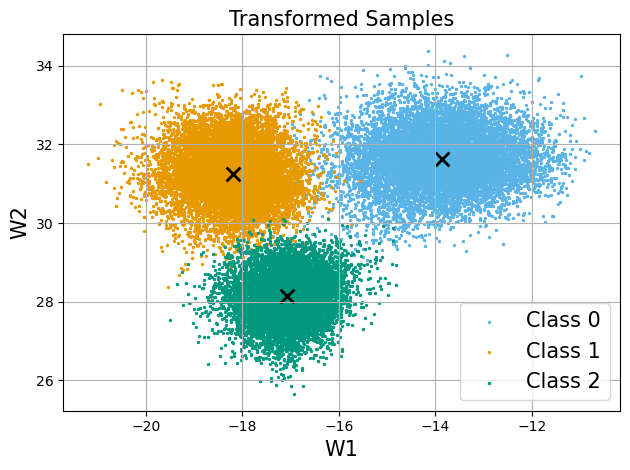

In [25]:
# Plot original transformed samples
plot_transformed(Xlda, Y, [med0, med1, med2], 'Transformed Samples', 1)

In [26]:
def rotate_and_plot(vec, Xlda, medians, Y, title, fig_num, ci, cf, axis_ref, axis='x'):
    base_vec = np.array([1, 0]) if axis == 'x' else np.array([0, 1])
    angle = np.arccos(np.dot(vec, base_vec) / (np.linalg.norm(vec) * np.linalg.norm(base_vec)))
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)],
    ])

    X_rotated = Xlda @ R
    W_rot = W @ R
    print(f"W_rot = {W_rot}")
    print(f"WTW = {W.T @ W}")
    #np.savetxt(f'W_oHLDA_{ci}_{cf}_{axis_ref}.txt', W_rot)
    pd.DataFrame(W_rot).to_csv(f'W_oHLDA_{ci}_{cf}_{axis_ref}.csv', index=False)
    med_rotated = [med @ R for med in medians]
    plot_transformed(X_rotated, Y, med_rotated, title, fig_num)

W_rot = [[-0.48939012 -0.33827661]
 [ 0.50930813  0.08454809]
 [-0.52452602 -0.01719171]
 [ 0.06533162  0.62167418]
 [-0.4112833   0.46239246]
 [-0.07463161  0.27342717]
 [-0.05989293  0.1254209 ]
 [-0.08074085 -0.22729833]
 [ 0.14668735 -0.09908261]
 [-0.12393349  0.35477419]]
WTW = [[ 1.00000000e+00 -1.36478925e-17]
 [-1.36478925e-17  1.00000000e+00]]
W_rot = [[-0.20262543  0.55935381]
 [-0.04782064 -0.51405869]
 [ 0.11683228  0.51163788]
 [ 0.58459197 -0.22135771]
 [ 0.55182017  0.28009862]
 [ 0.28341755  0.00260579]
 [ 0.13653216  0.02601026]
 [-0.1992745   0.13591648]
 [-0.13314428 -0.11664966]
 [ 0.37463157  0.02958754]]
WTW = [[ 1.00000000e+00 -1.36478925e-17]
 [-1.36478925e-17  1.00000000e+00]]
W_rot = [[-0.58948944  0.08022444]
 [ 0.43309815 -0.2810145 ]
 [-0.39891429  0.34101392]
 [ 0.46746175  0.41500182]
 [ 0.00810914  0.61878508]
 [ 0.12927318  0.25223152]
 [ 0.04035005  0.13300165]
 [-0.21289702 -0.1133952 ]
 [ 0.04150176 -0.1720818 ]
 [ 0.14772312  0.34554611]]
WTW = [[ 

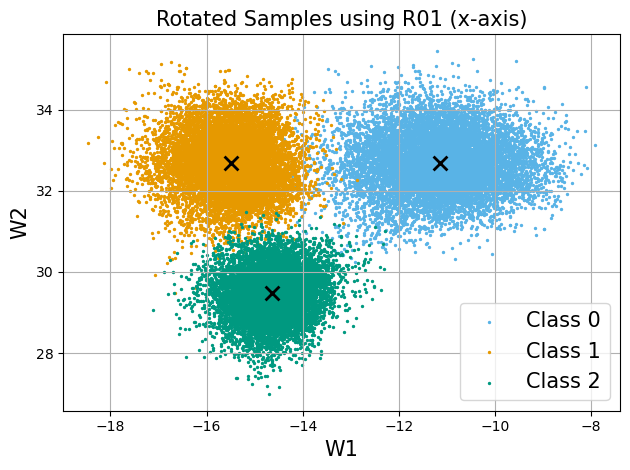

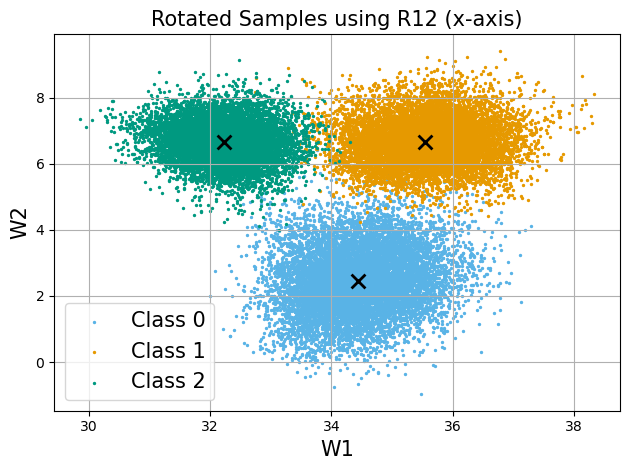

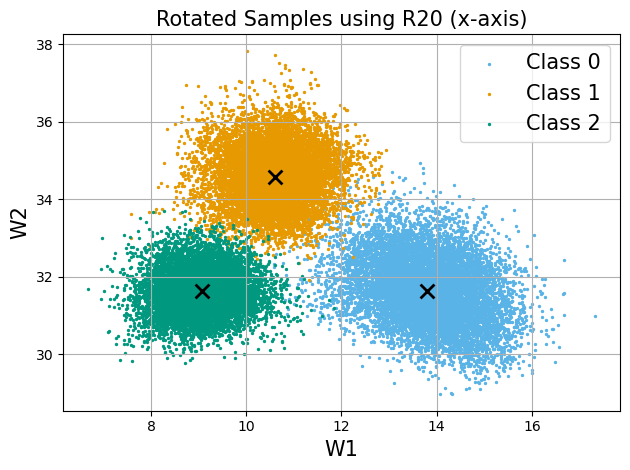

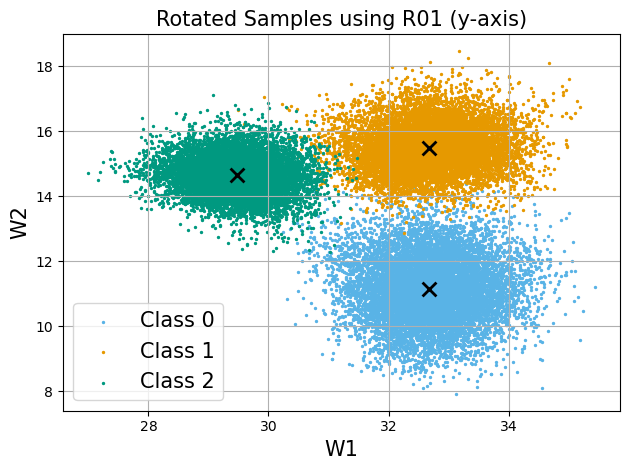

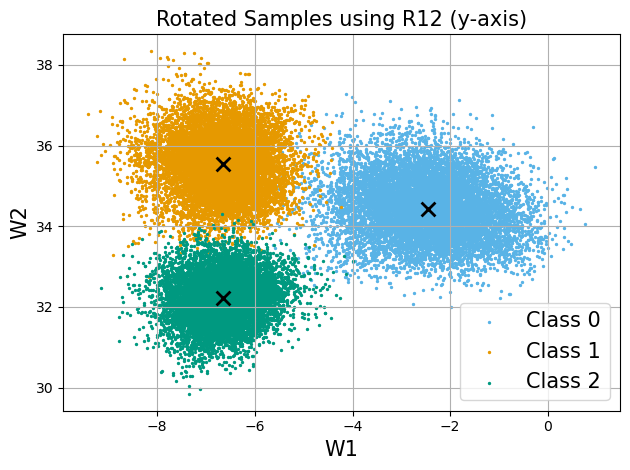

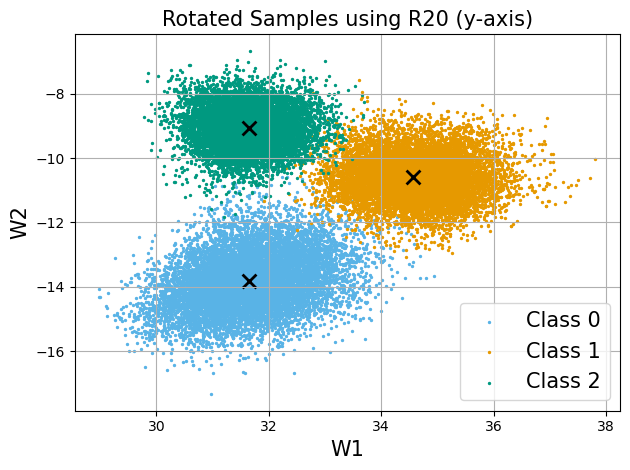

In [29]:
# Median vectors
vec01 = med0 - med1
vec12 = med1 - med2
vec20 = med0 - med2

# Rotation around x-axis
rotate_and_plot(vec01, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R01 (x-axis)', 2, 0, 1, 'x', axis='x')
rotate_and_plot(vec12, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R12 (x-axis)', 3, 1, 2, 'x', axis='x')
rotate_and_plot(vec20, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R20 (x-axis)', 4, 2, 0, 'x', axis='x')

# Median vectors
vec01 = med1 - med0
vec12 = med1 - med2
vec20 = med2 - med0

# Rotation around y-axis
rotate_and_plot(vec01, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R01 (y-axis)', 5, 0, 1, 'y', axis='y')
rotate_and_plot(vec12, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R12 (y-axis)', 6, 1, 2, 'y', axis='y')
rotate_and_plot(vec20, Xlda, [med0, med1, med2], Y, 'Rotated Samples using R20 (y-axis)', 7, 2, 0, 'y', axis='y')

plt.show()